In [29]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [30]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [31]:
class LLMstate(TypedDict):
    topic: str
    blog: str
    need_improvement: Literal["yes","no"]

In [32]:
graph = StateGraph(LLMstate)

In [33]:
def generate_blog(state: LLMstate) -> LLMstate:
    _topic = state["topic"]
    
    prompt = f"Write a small blog on the topic: {_topic}"

    state["blog"] = llm.invoke(prompt).content

    return state

In [34]:
class evaluatestruct(BaseModel):
    need_improvement: Literal["yes","no"] = Field(description="Does the blog need improvement?")

In [35]:
eval_llm = llm.with_structured_output(evaluatestruct)

In [36]:
def evalute_blog(state: LLMstate) -> LLMstate:
    _blog = state["blog"] 

    prompt = f"You are a strict Teacher/Professor. Very strictly evaluate the blog and respond wether the blog needs imporvement. Respond with yes or no. Blog: {_blog}"
    result = eval_llm.invoke(prompt)
    state["need_improvement"] = result.need_improvement

    return state
 

In [37]:
def conditional(state: LLMstate) -> Literal["optimize",END]:
        if state["need_improvement"] == "yes":
            return "optimize"
        else:
            return END   

In [38]:
def optimize(state: LLMstate) -> LLMstate:
    blog = state["blog"]

    prompt = f"I did not like this blog. Rewrite this while improving the content and proper structure. Blog: {blog}"

    result = llm.invoke(prompt)
    state["blog"] = result.content


In [39]:
graph.add_node("generate_blog",generate_blog)
graph.add_node("evalute_blog",evalute_blog)
graph.add_node("optimize",optimize)

In [40]:
graph.add_edge(START,"generate_blog")
graph.add_edge("generate_blog","evalute_blog")
graph.add_conditional_edges("evalute_blog",conditional)
graph.add_edge("optimize","evalute_blog")

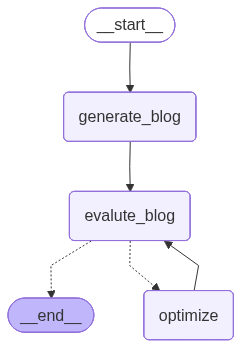

In [41]:
workflow = graph.compile()
workflow

In [42]:
init_state = {
    "topic": "AI is booming"
}

final_state = workflow.invoke(init_state)

In [45]:
print(final_state["blog"])

## The AI Revolution: It's Booming, and It's Everywhere!

Remember when Artificial Intelligence felt like something out of a sci-fi movie? Well, that future is now, and AI isn't just knocking on the door – it's burst through, transforming our world at an unprecedented pace. The AI boom is real, and it's exhilarating!

From sophisticated language models that can write poetry and code, to image generators that conjure stunning visuals from a few words, the advancements in AI are nothing short of breathtaking. It's not just about flashy new tools; AI is quietly revolutionizing industries across the board.

**Where do we see this boom? Everywhere!**

*   **In your daily life:** Think personalized recommendations on Netflix or Spotify, smart assistants answering your questions, or the incredibly accurate spam filters in your inbox.
*   **In healthcare:** AI is accelerating drug discovery, helping diagnose diseases earlier, and even assisting in complex surgeries.
*   **In business:** From o